# `viz_style` — shared theming and color palette

`viz_style` is pure plotting infrastructure, consumed by `sensor`,
`detectorsim2d`, `graphs`, `hopfield_tracking`, and `multiplicity`: one place
to switch between a "for print" and "for a talk" look, and one place
canonical colors live instead of five hardcoded copies.

It has three modules:
- `viz_style.theme` — `Theme`, the `PRINT`/`PRESENT` presets, and
  `get_theme`/`set_theme`/`use_theme`. No matplotlib import.
- `viz_style.palette` — plain color/colormap-name constants. Also no
  matplotlib import — both stay usable even for a non-matplotlib (SVG/PIL)
  consumer.
- `viz_style.mpl` — the *only* matplotlib-touching module: `style_axes` and
  `save_or_show`. Note this must be imported explicitly
  (`from viz_style.mpl import ...`); it is **not** re-exported from the
  top-level `viz_style` package.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from viz_style import Theme, PRINT, PRESENT, get_theme, set_theme, use_theme, palette
from viz_style.mpl import style_axes, save_or_show

print(PRINT)
print(PRESENT)


Theme(name='print', show_title=True, show_spatial_axes=True, savefig_kwargs={'dpi': 150, 'bbox_inches': 'tight'})
Theme(name='present', show_title=False, show_spatial_axes=False, savefig_kwargs={'dpi': 150, 'bbox_inches': 'tight'})


## Two themes, one plotting function

Every `plot_*` function across the consuming packages takes an optional
trailing `theme: Theme | None = None`, resolved via `theme = theme or
get_theme()`. Below, one plotting function draws both a *spatial* panel
(detector/hit positions) and a *statistical* panel (a histogram), then we
render it once under each theme.

`spatial=True` under `PRESENT` drops ticks, spines, labels, *and* the legend
together — a deliberate all-or-nothing choice for geometric displays.
`spatial=False` (statistical plots) never loses its axes/labels/legend;
only the title is theme-gated, since a plot like a histogram is unreadable
without a labeled axis.


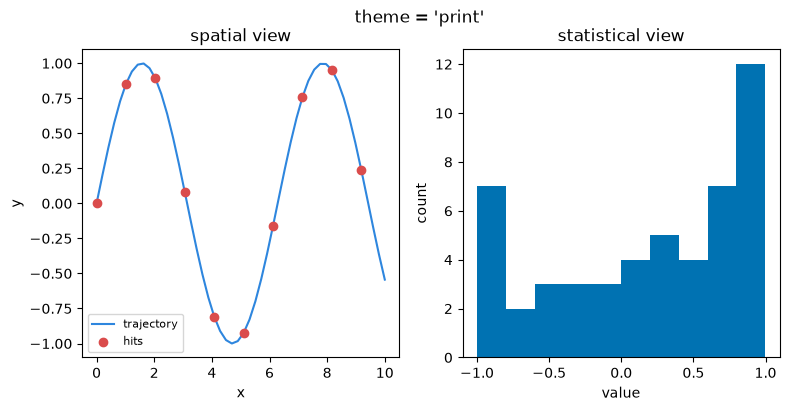

In [2]:
x = np.linspace(0, 10, 50)
y = np.sin(x)

def make_demo_plot(theme):
    fig, (ax_spatial, ax_stat) = plt.subplots(1, 2, figsize=(9, 4))

    ax_spatial.plot(x, y, color=palette.TRUTH, label="trajectory")
    ax_spatial.scatter(x[::5], y[::5], color=palette.CLUSTER, label="hits", zorder=3)
    style_axes(ax_spatial, theme, spatial=True, title="spatial view",
               xlabel="x", ylabel="y", legend=True)

    ax_stat.hist(y, bins=10, color=palette.CATEGORICAL_OKABE_ITO[0])
    style_axes(ax_stat, theme, spatial=False, title="statistical view",
               xlabel="value", ylabel="count")

    fig.suptitle(f"theme = {theme.name!r}")
    return fig

fig_print = make_demo_plot(PRINT)


In [ ]:
fig_present = make_demo_plot(PRESENT)


## Setting the theme for a block of code

`use_theme(theme)` is a context manager: it sets `get_theme()`'s return
value for the `with` block and restores the previous value afterward, even
on exception. This is the safe way to apply a theme across several plotting
calls in a notebook without leaking state into later cells.

`set_theme(theme)` mutates the process-wide default directly and is *not*
undone automatically — real CLIs in this repo never use it (they always
pass `theme=` explicitly), and a notebook should prefer `use_theme(...)` for
the same reason.


In [3]:
with use_theme(PRESENT):
    print("inside the block:", get_theme().name)
print("outside the block, back to:", get_theme().name)


inside the block: present
outside the block, back to: print


## The palette

Every color used across the plotting packages lives here as a plain string
constant — semantic names (`TRUTH`, `CLUSTER`, `HIT`, `VERTEX`, `EDGE`, ...)
plus the `CATEGORICAL_OKABE_ITO` colorblind-safe 6-hue cycle used for
distinguishing many same-role items (e.g. different tracks).

Note `CLASS_COLORS` (used for a *different* categorical purpose, e.g.
multiplicity classes) is deliberately a separate 5-hue palette, not yet
reconciled with `CATEGORICAL_OKABE_ITO` even though both are categorical —
don't assume they're interchangeable.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 1.2))
for i, color in enumerate(palette.CATEGORICAL_OKABE_ITO):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
ax.set_xlim(0, len(palette.CATEGORICAL_OKABE_ITO))
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("CATEGORICAL_OKABE_ITO (colorblind-safe cycle)")
